# Marketplace Safety – Machine Learning

## Gruppuppgift / individuell inlämning

I det här projektet bygger jag en lösning för att hjälpa ett Trust & Safety team att prioritera misstänkta händelser i en marketplace-app.

Varje rad i datasetet representerar en händelse på plattformen, till exempel en annons eller ett meddelande. Målet är att klassificera om händelsen är misstänkt eller inte.

Target-variabeln är:

- `is_suspicious = 1`: misstänkt händelse
- `is_suspicious = 0`: ej misstänkt händelse

Eftersom uppgiften handlar om prioritering är målet inte att få 100% rätt, utan att bygga en modell som fungerar rimligt bra, går att förklara och kan användas som beslutsstöd.

In [50]:
# Grundläggande bibliotek
from pathlib import Path
import joblib

import numpy as np
import pandas as pd

# Visualisering
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# Inställningar
RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [51]:
# Sökvägar
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "historical_data.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/data/raw/historical_data.csv')

In [52]:
df = pd.read_csv(DATA_PATH)

df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [53]:
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")

df.info()

Antal rader: 12000
Antal kolumner: 18
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  cont

## 1. Dataförståelse

Datasetet innehåller 12 000 historiska händelser från en marketplace-plattform. Varje rad motsvarar en händelse, till exempel en annons eller ett meddelande.

Datan innehåller både numeriska signaler, som pris, kontots ålder och antal tidigare rapporter, samt kategoriska signaler, som region, device, kategori och event-typ.

Target-kolumnen heter `is_suspicious` och visar om händelsen tidigare har bedömts som misstänkt eller inte.

In [54]:
target_counts = df["is_suspicious"].value_counts().sort_index()
target_percent = df["is_suspicious"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Antal": target_counts,
    "Andel (%)": target_percent.round(2)
})

target_distribution

,Antal,Andel (%)
is_suspicious,,
0,10776,89.8
1,1224,10.2


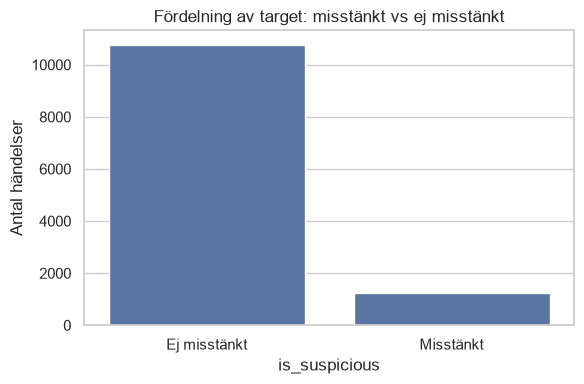

In [55]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_suspicious"
)

plt.title("Fördelning av target: misstänkt vs ej misstänkt")
plt.xlabel("is_suspicious")
plt.ylabel("Antal händelser")
plt.xticks([0, 1], ["Ej misstänkt", "Misstänkt"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

### Target-fördelning

Target-fördelningen visar att majoriteten av händelserna inte är misstänkta. Ungefär 10% av raderna är markerade som misstänkta.

Det betyder att datan är obalanserad. Därför räcker det inte att bara titta på accuracy. En modell kan få hög accuracy genom att nästan alltid gissa "ej misstänkt", men det skulle inte hjälpa Trust & Safety-teamet så mycket.

Vii nehöver därför även titta på mått som precision, recall, F1 och PR-AUC.

In [56]:
missing_values = pd.DataFrame({
    "Antal saknade": df.isna().sum(),
    "Andel saknade (%)": (df.isna().mean() * 100).round(2)
})

missing_values = missing_values[missing_values["Antal saknade"] > 0]
missing_values

,Antal saknade,Andel saknade (%)
region,340,2.83
price,818,6.82
time_to_first_response_min,590,4.92


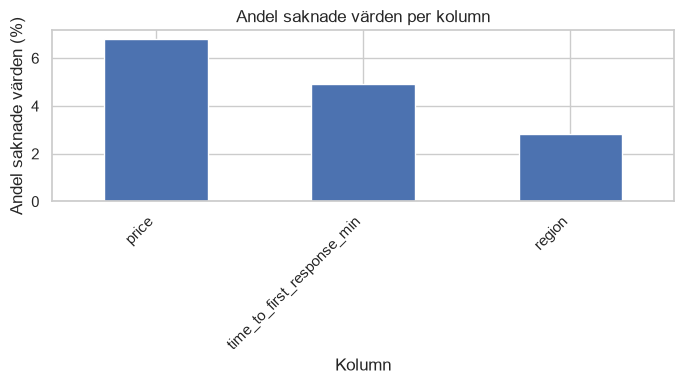

In [57]:
plt.figure(figsize=(7, 4))

missing_values["Andel saknade (%)"].sort_values(ascending=False).plot(kind="bar")

plt.title("Andel saknade värden per kolumn")
plt.xlabel("Kolumn")
plt.ylabel("Andel saknade värden (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values.png", dpi=150)
plt.show()

### Saknade värden

Det finns saknade värden i `region`, `price` och `time_to_first_response_min`.

Det är realistiskt för den här typen av data. Alla annonser kanske inte har ett pris, alla händelser kanske inte har en tydlig region och vissa svarstider kan saknas.

Jag tar intee bort dessa rader, eftersom det skulle göra att vi tappar data. I stället hanteras saknade värden senare i en pipeline:

- numeriska kolumner fylls med medianvärde
- kategoriska kolumner fylls med ett särskilt värde, till exempel `"missing"`

Det gör också att samma hantering kan användas på både train, test och framtida `new_data.csv`.

In [58]:
event_type_summary = (
    df.groupby("event_type")["is_suspicious"]
    .agg(["count", "mean"])
    .rename(columns={
        "count": "Antal händelser",
        "mean": "Andel misstänkta"
    })
)

event_type_summary["Andel misstänkta (%)"] = (event_type_summary["Andel misstänkta"] * 100).round(2)
event_type_summary = event_type_summary.drop(columns="Andel misstänkta")

event_type_summary.sort_values("Andel misstänkta (%)", ascending=False)

,Antal händelser,Andel misstänkta (%)
event_type,,
message_send,3465,10.71
ad_post,8535,9.99


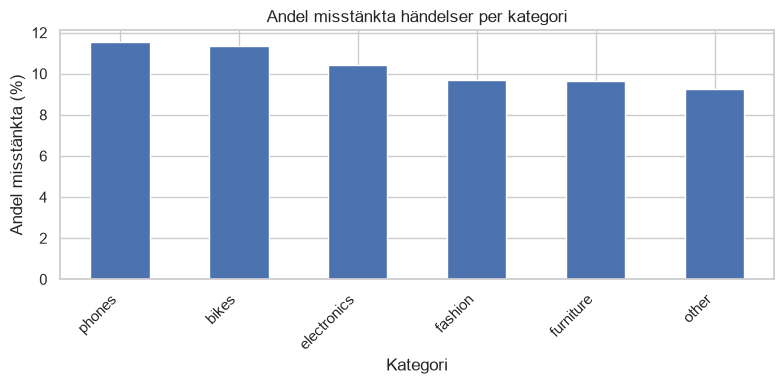

In [59]:
category_risk = (
    df.groupby("category")["is_suspicious"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(8, 4))

category_risk.plot(kind="bar")

plt.title("Andel misstänkta händelser per kategori")
plt.xlabel("Kategori")
plt.ylabel("Andel misstänkta (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "suspicious_rate_by_category.png", dpi=150)
plt.show()

### Skillnader mellan grupper

EDA:n visar att risken inte är helt jämnt fördelad mellan olika typer av händelser och kategorier. Vissa grupper har högre andel misstänkta händelser än andra.

Det betyder att kategoriska variabler som `event_type`, `category`, `region` och `device` kan vara användbara signaler för modelllen.

Samtidigt måste modellen tränas på ett leakage säkert sätt, så encoding och imputation görs senare inne i en scikit learn pippeline.

## 2. Train/test-split och preprocessing

För att kunna utvärdera modellen på ett rättvist sätt delar jag upp `historical_data.csv` i train och test.

Jag använder en strattifierad split eftersom target är obalanserat. Det betyder att ungefär samma andel misstänkta händelser finns i både train och test.

För att undvika data leakage görs preprocessing i en scikit learn pipeline. Det innebär att imputation, skalning och one-hot encoding lärs på träningsdatan och sedan appliceras på testdatan.

In [60]:
# Target
target = "is_suspicious"

# Kolumner som inte ska användas som features
# id är bara en rad-ID och ska inte användas för att träna modellen.
drop_columns = ["id", target]

X = df.drop(columns=drop_columns)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (12000, 16)
y shape: (12000,)


,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min
0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3
1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6
2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2
3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8
4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

split_distribution = pd.DataFrame({
    "Train (%)": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Test (%)": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})

split_distribution

Train shape: (9600, 16)
Test shape: (2400, 16)


,Train (%),Test (%)
is_suspicious,,
0,89.8,89.79
1,10.2,10.21


In [62]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print("Numeriska features:")
print(numeric_features)

print("\nKategoriska features:")
print(categorical_features)

Numeriska features:
['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d', 'verification_level', 'price', 'num_images', 'message_length', 'contains_off_platform', 'urgency_words', 'payment_attempt', 'time_to_first_response_min']

Kategoriska features:
['event_type', 'category', 'region', 'device']


In [63]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [64]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)

Prepared train shape: (9600, 27)
Prepared test shape: (2400, 27)


### Preprocessing-val

Jag tar bort `id` eftersom den bara identifierar raden och inte borde användas som en signal i modellen.

De numeriska kolumnerna hanteras med median-imputation eftersom medianen är robbust mot extrema värden. Därefter skalas de numeriska värdena vilket särskilt hjälper modeller som Logistic Regression.

De kategoriska kolumnerna hanteras med konstant imputation där saknade värden ersätts med `"missing"`. Sedan används one-hot encoding. `handle_unknown="ignore"` gör att pipeline:en även klarar nya kategorier i framtida data utan att krascha.

## 3. Modellering och jämförelse

I det här steget jämför jag flera modeller på träningsdatan med cross-validation.

Jag börjar med en baseline moddell som alltid gissar den vanligaste klassen. Eftersom datan är obalanserad är det viktigt att jämföra mot en sån baseline. Om en mer avancerad modell inte slår baseline på relevanta metrics finns det ingen poäng med att använda den.

Jag jämför sedan flera modeller:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Jag tittar inte bara på accuracy, eftersom bara ungefär 10% av händelserna är misstänkta. Därför jämför jag även precision, recall, F1, ROC-AUC och PR-AUC.

In [65]:
models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

models

{'Baseline': DummyClassifier(strategy='most_frequent'),
 'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=150,
                        n_jobs=-1, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

In [66]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [67]:
cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_results.append({
        "Modell": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    })

model_comparison = pd.DataFrame(cv_results)

metric_columns = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
model_comparison[metric_columns] = model_comparison[metric_columns].round(3)

model_comparison.sort_values("F1", ascending=False)

,Modell,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Random Forest,0.750,0.213,0.540,0.306,0.739,0.258
1,Logistic Regression,0.686,0.192,0.649,0.297,0.736,0.281
2,Decision Tree,0.671,0.183,0.638,0.283,0.708,0.216
4,Gradient Boosting,0.898,0.478,0.069,0.121,0.757,0.287
0,Baseline,0.898,0.000,0.000,0.000,0.500,0.102


In [68]:
model_comparison_path = PROJECT_ROOT / "reports" / "model_comparison.csv"

model_comparison.to_csv(model_comparison_path, index=False)

model_comparison_path

WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/reports/model_comparison.csv')

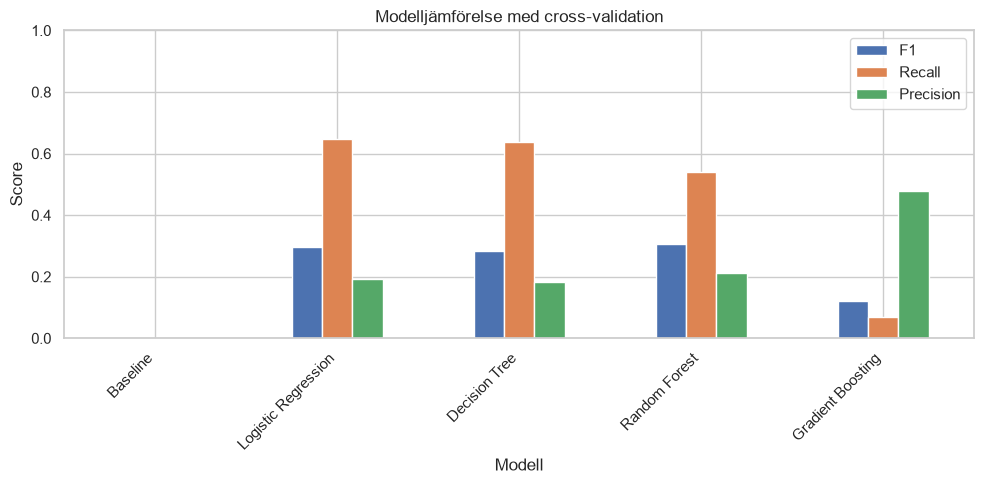

In [69]:
comparison_plot_data = model_comparison.set_index("Modell")[["F1", "Recall", "Precision"]]

ax = comparison_plot_data.plot(kind="bar", figsize=(10, 5))

plt.title("Modelljämförelse med cross-validation")
plt.xlabel("Modell")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=150)
plt.show()

### Tolkning av modelljämförelsen

Baseline modellen är viktig eftersom den visar hur lite accuracy säger i en obalanserat problem. Om modellen nästan alltid gissar "ej misstänkt" kan den få hög accuracy, men den hittar inga misstänkta händelser.

Därför jämför jag modellerna med flera metrics:

- **Recall** visar hur stor andel av de misstänkta händelserna modellen hittar.
- **Precision** visar hur många av de flaggade händelserna som faktiskt är misstänkta.
- **F1** balanserar precision och recall.
- **PR-AUC** är extra relevant när klassen misstänkt är ovanlig.

Slutligt modellval görs inte bara utifrån högsta score, utan också utifrån kravkortet och hur modellen ska användas i praktiken.

Eftersom mitt valda kravkort fokuserar på Trust & Safety och att minimera false negatives kommer jag lägga extra vikt vid recall och PR-AUC. Samtidigt behöver precision fortfarande följas upp, eftersom teamet har begränsad tid och inte kan granska hur många falsklarm som helst.

## Kravkort och prioritering

Eftersom jag gör uppgiften individuellt och inte har fått ett gruppspecifikt kravkort har jag valt ett rimligt kravkort för att kunna genomföra projektet konsekvent.

**Stakeholder:** Trust & Safety-teamet  
**Prioritet:** Minimera false negatives, alltså att undvika att missa misstänkta händelser.

Motiveringen är att Trust & Safety-teamet behöver prioritera vilka annonser och meddelanden som ska granskas först. I det här sammanhhanget är det ofta värre att missa en faktisk bluff eller ettt misstänkt beteende än att råka flagga några extra händelser för manuell granskning.

Det betyder att jag kommer lägga extra vikt vid:

- recall
- PR-AUC
- false negatives
- threshold/prioritering som hittar fler misstänkta händelser

Modellen ska inte användas för att automatiskt straffa användare, utan som ett beslutsstöd för att prioritera manuell granskning.

## 4. Val av modell och hyperparameter-tuning

Utifrån modelljämförelsen väljer jag **Logistic Regression** som final modell.

Anledningen är att kravkortet fokuserar på Trust & Safety-teamet och att minska risken för false negatives. I praktiken betyder det att modellen bör hitta så många misstänkta händelser som möjligt, även om det innebär att vissa extra händelser behöver granskas manuellt.

Logistic Regression är också relativt lätt att förklara jämfört med mer komplexa modeller. Det passar bra eftersom lösningen ska kunna presenteras för stakeholders som inte nödvändigtvis är tekniska.

Jag gör hyperparameter-tuning på:

- `C`: styr hur stark regulariseringen är
- `class_weight`: styr hur mycket modellen ska väga den misstänkta klassen jämfört med den icke-misstänkta

Eftersom datan är obalanserad och uppgiften handlar om prioritering använder jag `average_precision` som tuning-metric. Det passar bättre än accuracy eftersom den positiva klassen är relativt ovanlig.

In [70]:
final_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

final_model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [71]:
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [
        "balanced",
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 7}
    ]
}

param_grid

{'model__C': [0.1, 1, 10],
 'model__class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}]}

In [72]:
grid_search = GridSearchCV(
    estimator=final_model_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Bästa parametrar:")
print(grid_search.best_params_)

print("\nBästa CV-score:")
print(round(grid_search.best_score_, 3))

Bästa parametrar:
{'model__C': 10, 'model__class_weight': {0: 1, 1: 3}}

Bästa CV-score:
0.284


In [73]:
tuning_results = pd.DataFrame(grid_search.cv_results_)

tuning_results_table = tuning_results[
    [
        "param_model__C",
        "param_model__class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

tuning_results_table = tuning_results_table.rename(columns={
    "param_model__C": "C",
    "param_model__class_weight": "class_weight",
    "mean_test_score": "Mean CV PR-AUC",
    "std_test_score": "Std CV PR-AUC",
    "rank_test_score": "Rank"
})

tuning_results_table["Mean CV PR-AUC"] = tuning_results_table["Mean CV PR-AUC"].round(3)
tuning_results_table["Std CV PR-AUC"] = tuning_results_table["Std CV PR-AUC"].round(3)

tuning_results_table

,C,class_weight,Mean CV PR-AUC,Std CV PR-AUC,Rank
9,10.0,"{0: 1, 1: 3}",0.284,0.026,1
5,1.0,"{0: 1, 1: 3}",0.284,0.026,2
1,0.1,"{0: 1, 1: 3}",0.284,0.026,3
6,1.0,"{0: 1, 1: 5}",0.283,0.026,4
2,0.1,"{0: 1, 1: 5}",0.283,0.026,5
10,10.0,"{0: 1, 1: 5}",0.283,0.026,6
7,1.0,"{0: 1, 1: 7}",0.282,0.026,7
11,10.0,"{0: 1, 1: 7}",0.282,0.026,8
3,0.1,"{0: 1, 1: 7}",0.282,0.026,9
8,10.0,balanced,0.281,0.026,10


In [74]:
tuning_results_path = PROJECT_ROOT / "reports" / "tuning_results.csv"

tuning_results_table.to_csv(tuning_results_path, index=False)

tuning_results_path

WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/reports/tuning_results.csv')

In [75]:
best_model = grid_search.best_estimator_

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['day','event_type','category',...,'urgency_words','payment_attempt', 'time_to_first_response_min']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [76]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
    "PR-AUC": average_precision_score(y_test, y_test_proba)
}

test_metrics_df = pd.DataFrame([test_metrics]).round(3)

test_metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.876,0.341,0.233,0.277,0.739,0.273


In [77]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Ej misstänkt", "Misstänkt"]
))

              precision    recall  f1-score   support

Ej misstänkt       0.92      0.95      0.93      2155
   Misstänkt       0.34      0.23      0.28       245

    accuracy                           0.88      2400
   macro avg       0.63      0.59      0.60      2400
weighted avg       0.86      0.88      0.87      2400



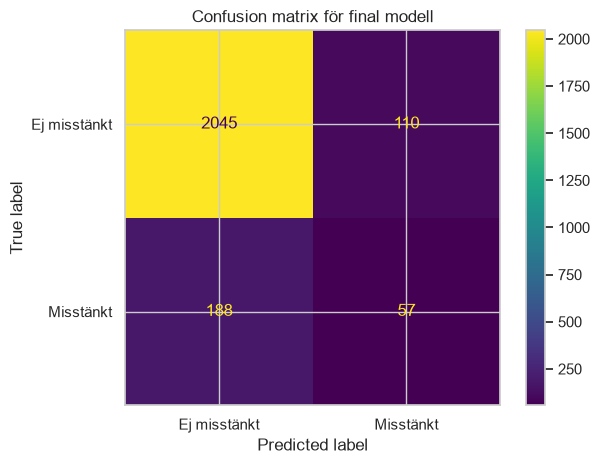

In [78]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ej misstänkt", "Misstänkt"]
)

disp.plot(values_format="d")

plt.title("Confusion matrix för final modell")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_model_confusion_matrix.png", dpi=150)
plt.show()

In [79]:
test_metrics_path = PROJECT_ROOT / "reports" / "final_model_test_metrics.csv"

test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_path

WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/reports/final_model_test_metrics.csv')

In [80]:
model_path = MODELS_DIR / "final_model.joblib"

joblib.dump(best_model, model_path)

model_path

WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/models/final_model.joblib')

### Resultat efter tuning

Efter tuning används den bästa Logistic Regression pipelin:en som final modell. Pipelinen innehåller både preprocesssing och modellen, vilket gör att samma steg används konsekvent på train, test och senare `new_data.csv`.

Jag valde att optimera modellen med `average_precision`, eftersom den positiva klassen är ovanlig och projektet handlar om att prioritera misstänkta händelser. Accuracy hade varit missvisande eftersom en modell kan få hög accuracy genom att nästan alltid förutsäga "ej misstänkt".

Confusion matrixen är extra viktig här eftersom den visar hur många false positives och false negatives modellen ger. För Trust & Safety är false negatives särskilt viktiga, eftersom det innebär att en misstänkt händelse inte prioriteras för granskning.

## 5. Threshold och prioritering

Eftersom projektet handlar om Trust & Safety räcker det inte att bara använda modellens standard-threshold på 0.50.

Standard-threshold betyder att modellen flagggar en händelse som misstänkt om sannolickheten är minst 50%. Det kan vara rimligt i vissa problem, men här är målet att prioritera misstänkta händelser för manuell granskning.

Mitt kravkort fokuserar på att minska false negatives. Därför testar jag flera thresholds och väljer en nivå som ger hög recall, men där precision fortfarande är rimlig.

Strategin är:

- använda modellens sannolikhet för misstänkt händelse
- testa flera thresholds
- välja en threshold som ger minst 80% recall om möjligt
- bland thresholds som når detta väljs den med högst precision

Det passar Trust & Safety eftersom modellen används som ett prioriteringsstöd, inte som ett automatiskt straffsystem.

In [81]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    threshold_results.append({
        "Threshold": threshold,
        "Flaggade": int(y_pred_threshold.sum()),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df[["Threshold", "Precision", "Recall", "F1"]] = (
    threshold_results_df[["Threshold", "Precision", "Recall", "F1"]].round(3)
)

threshold_results_df

,Threshold,Flaggade,TP,FP,FN,TN,Precision,Recall,F1
0,0.10,1952,227,1725,18,430,0.116,0.927,0.207
1,0.15,1566,214,1352,31,803,0.137,0.873,0.236
2,0.20,1152,198,954,47,1201,0.172,0.808,0.283
3,0.25,835,169,666,76,1489,0.202,0.690,0.313
4,0.30,581,135,446,110,1709,0.232,0.551,0.327
5,0.35,424,115,309,130,1846,0.271,0.469,0.344
6,0.40,315,89,226,156,1929,0.283,0.363,0.318
7,0.45,242,75,167,170,1988,0.310,0.306,0.308
8,0.50,167,57,110,188,2045,0.341,0.233,0.277
9,0.55,116,43,73,202,2082,0.371,0.176,0.238


In [82]:
target_recall = 0.80

valid_thresholds = threshold_results_df[
    threshold_results_df["Recall"] >= target_recall
].copy()

if len(valid_thresholds) > 0:
    selected_threshold_row = valid_thresholds.sort_values(
        ["Precision", "Threshold"],
        ascending=[False, False]
    ).iloc[0]
else:
    selected_threshold_row = threshold_results_df.sort_values(
        "Recall",
        ascending=False
    ).iloc[0]

selected_threshold = float(selected_threshold_row["Threshold"])

selected_threshold_row

Threshold       0.200
Flaggade     1152.000
TP            198.000
FP            954.000
FN             47.000
TN           1201.000
Precision       0.172
Recall          0.808
F1              0.283
Name: 2, dtype: float64

In [83]:
y_test_pred_selected = (y_test_proba >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_selected).ravel()

selected_threshold_metrics = {
    "Selected threshold": selected_threshold,
    "Flaggade för granskning": int(y_test_pred_selected.sum()),
    "True positives": tp,
    "False positives": fp,
    "False negatives": fn,
    "True negatives": tn,
    "Precision": precision_score(y_test, y_test_pred_selected, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_selected),
    "F1": f1_score(y_test, y_test_pred_selected)
}

selected_threshold_metrics_df = pd.DataFrame([selected_threshold_metrics]).round(3)

selected_threshold_metrics_df

,Selected threshold,Flaggade för granskning,True positives,False positives,False negatives,True negatives,Precision,Recall,F1
0,0.2,1152,198,954,47,1201,0.172,0.808,0.283


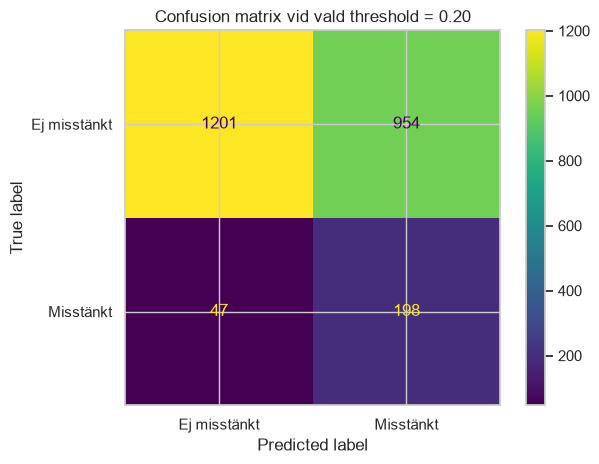

In [84]:
cm_selected = confusion_matrix(y_test, y_test_pred_selected)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_selected,
    display_labels=["Ej misstänkt", "Misstänkt"]
)

disp.plot(values_format="d")

plt.title(f"Confusion matrix vid vald threshold = {selected_threshold:.2f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "selected_threshold_confusion_matrix.png", dpi=150)
plt.show()

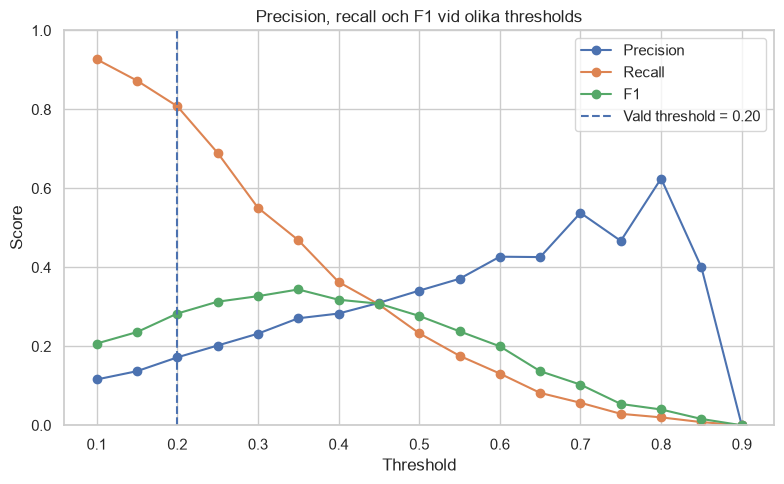

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1"], marker="o", label="F1")

plt.axvline(selected_threshold, linestyle="--", label=f"Vald threshold = {selected_threshold:.2f}")

plt.title("Precision, recall och F1 vid olika thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_metrics.png", dpi=150)
plt.show()

In [86]:
threshold_results_path = PROJECT_ROOT / "reports" / "threshold_results.csv"
selected_threshold_path = PROJECT_ROOT / "reports" / "selected_threshold_metrics.csv"

threshold_results_df.to_csv(threshold_results_path, index=False)
selected_threshold_metrics_df.to_csv(selected_threshold_path, index=False)

threshold_results_path, selected_threshold_path

(WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/reports/threshold_results.csv'),
 WindowsPath('c:/Users/SG199/Desktop/VS CODE REPOS/marketplace-safety-ml/reports/selected_threshold_metrics.csv'))

### Vald threshold och konsekvens

Jag valde threshold utifrån kravkortet: Trust & Safety vill framför allt minska risken att misstänkta händelser missas.

Därför är recall viktigare än accuracy i det här projektet. En lägre threshold gör att fler händelser flaggas för granskning. Det ökar ofta recallmen kan samtidigt ge flera false positives.

Det är en rimlig trade off här eftersom modelllen inte automatiskt ska ta bort annonser eller straffa användare. Den ska bara hjälpa teamet att prioritera vilka händelser som borde granskas först.

Konsekvensen av threshold valet visas i confusion matrixen:

- **False negatives** är misstänkta händelser som modellen missar.
- **False positives** är icke-misstänkta händelser som ändå skickas till granskning.

För vårt kravkort är false negatives mest kritiska, men false positives behöver fortfarande hållas på en nivå som teamet klarar av att hantera.